# Tropical Algorithms Meet Operations Research: The Assignment Problem

## Imports and Configuration

In [36]:
# Standard library
import json
import math
import random
import sys
import timeit
from datetime import datetime, timedelta
from pathlib import Path

# Numerical computing and data
import numpy as np
import numpy.testing as npt
import pandas as pd
import scipy.linalg
import scipy.sparse as sp
from scipy.optimize import linear_sum_assignment

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Geospatial analysis
import geopandas as gpd
import contextily as ctx

# Project code
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.solvers import (
    tropcost,
    tropassignment,
    tropsubsetDPcost,
    tropsubsetDPassignment,
    forbiddentropsubsetDPassignment,
    MIPassignment,
    LPassignment,
)

## Mathematical Explanation

Imagine $n$ workers and $n$ jobs, and let $x_{ij}$ be the cost of assigning worker $i$ to job $j$. Each worker must be assigned to exactly one job and each job to exactly one worker, so an assignment corresponds to a permutation $\sigma \in S_n$. Its total cost is

$$
\sum_{i=1}^n x_{i,\sigma(i)}.
$$

The assignment problem is therefore

$$
\min_{\sigma \in S_n} \sum_{i=1}^n x_{i,\sigma(i)}.
$$

This objective has a natural interpretation in **tropical (min-plus) algebra**. In ordinary arithmetic, the basic operations are addition and multiplication. In the min-plus setting, these are replaced by

$$
a \oplus b = \min(a,b),
\qquad
a \odot b = a+b.
$$

To see the connection, let $X=(x_{ij})$ be an $n\times n$ matrix. The classical permanent of $X$ is

$$
\operatorname{perm}(X)
=
\sum_{\sigma\in S_n}
\prod_{i=1}^n x_{i,\sigma(i)}.
$$

Replacing classical addition by minimum and multiplication by addition gives the **tropical permanent**

$$
\operatorname{tropperm}(X)
=
\min_{\sigma\in S_n}
\sum_{i=1}^n x_{i,\sigma(i)}.
$$

Thus, the tropical permanent is exactly the optimal value of the assignment problem.

This connection also suggests a direct algorithm. The classical permanent can be expanded recursively using a tropical analogue of cofactor exapansion. Classically, the permanent of $X$ can be computed as follows. Let $X_{ij}$ be the matrix obtained by deleting row $1$ and column $j$. Then, it is a classical fact from linear algebra that
$$
\operatorname{perm}(X) = \sum_{j = 1}^n  x_{1j} \cdot \operatorname{perm}(X_{1j})
$$
Tropically, it also holds that
$$
\operatorname{tropperm}(X) = \min_{j = 1,\ldots,n} (x_{1j} + \operatorname{tropperm}(X_{1j}))
$$
So we will use this strategy.


The questions we investigate are:

1. How does this direct tropical algorithm perform computationally?
2. How much can it be improved by avoiding repeated subproblems and exploiting structure in the cost matrix?
3. How do these tropical methods compare with specialized and general-purpose optimization methods?

## Solver Demonstrations

### Small Example Matrix

We make a small example matrix that we will work from. Note that there can be multiple solutions to the assignment problem if more than one assignment produces the minimal total cost.

In [2]:
X = np.random.randint(0, 100, size=(7,7))
print(X)

[[93  5 66 91 33 22 32]
 [60 36  6  3 46 83 85]
 [83 30 55 12 43 23 70]
 [28  8  8 38 73 24 62]
 [66 82  5  2 62 60 96]
 [43 25 73  6 56 88 43]
 [95  8 30 86 68 80 96]]


### Naive tropical algorithm

The output is first: the total minimal cost, and second: an assignment that achieves this, in the form of pairs of a row i and a column j that are matched.

In [3]:
tropassignment(X)

[np.int64(143),
 array([[0, 4],
        [1, 3],
        [2, 5],
        [3, 0],
        [4, 2],
        [5, 6],
        [6, 1]])]

### Tropical Subset Dynamic Programming

The above algorithm is very inefficient because it is solving the same sub-problems repeatedly. We can achieve performance improvements by taking a subset DP approach, explained as follows.

Fix a cost matrix $X$. Let $S$ denote a subset of the columns. Let $f(S)$ be the optimal solution assigning the first $|S|$ rows to the columns indexed by $S$. Then, we have the following expression:
$$
f(S) = \min_j (f(S \backslash \{j\} + x_{|S|,j}))
$$
this is equivalent to the ``tropical cofactor expansion'' written above. However, if we remember the values $f(S)$ as they are computed, then when this sub-problem is encountered again it does not need to be re-computed. We will store the answers in a dictionary.

In [4]:
tropassignment(X)

[np.int64(143),
 array([[0, 4],
        [1, 3],
        [2, 5],
        [3, 0],
        [4, 2],
        [5, 6],
        [6, 1]])]

### Sparsity-aware tropical subset DP

Now, we make use of potential structure in the matrix by ignoring paths corresponding to costs $M$ that are significantly larger than the rest. By default M = 999

In [5]:
forbiddentropsubsetDPassignment(X,10000)

[np.int64(143), {6: 1, 5: 6, 4: 2, 3: 0, 2: 5, 1: 3, 0: 4}]

### Hungarian Algorithm

The Hungarian Algorithm solves the assignment problem in poynomial time O(n^3). It is implemented in Python using the scipy.optimize.linear_sum_assignment function.

In [6]:
print(linear_sum_assignment(X))
X[linear_sum_assignment(X)].sum()

(array([0, 1, 2, 3, 4, 5, 6]), array([4, 3, 5, 0, 2, 6, 1]))


np.int64(143)

### Mixed-Integer Programming Formulation

The assignment problem can also be formulated as a mixed-integer program. For each worker $i$ and job $j$, define a binary decision variable

$$
y_{ij} =
\begin{cases}
1 & \text{if worker } i \text{ is assigned to job } j,\\
0 & \text{otherwise}.
\end{cases}
$$

The objective is to minimize the total assignment cost:

$$
\min \sum_{i=1}^n \sum_{j=1}^n x_{ij}y_{ij}.
$$

Each worker must be assigned to exactly one job,

$$
\sum_{j=1}^n y_{ij} = 1
\qquad \text{for each } i,
$$

and each job must be assigned to exactly one worker,

$$
\sum_{i=1}^n y_{ij} = 1
\qquad \text{for each } j.
$$

Finally,

$$
y_{ij} \in \{0,1\}.
$$

This formulation expresses the same assignment problem in the standard language of mathematical optimization. Unlike the tropical algorithms above, it can be passed directly to a general-purpose MIP solver; here, I solve it using SCIP through OR-Tools.

In [7]:
MIPassignment(X)

[np.int64(143),
 array([[0, 4],
        [1, 2],
        [2, 5],
        [3, 0],
        [4, 3],
        [5, 6],
        [6, 1]])]

### Linear Programming Relaxation

For the assignment problem, we can relax the integrality requirement on the decision variables and solve a linear program instead. Rather than requiring

$$
y_{ij} \in \{0,1\},
$$

we allow

$$
0 \leq y_{ij} \leq 1.
$$

At first glance, this appears to permit fractional assignments. However, the assignment problem has special polyhedral structure: its feasible region is the **Birkhoff polytope**, whose vertices are precisely the permutation matrices. Equivalently, the assignment constraint matrix is totally unimodular, so with integral right-hand sides the LP has an integral optimal solution.

Because a linear objective over a polytope attains its optimum at a vertex (or, when multiple optima exist, on a face containing an optimal vertex), there is always an optimal solution with

$$
y_{ij} \in \{0,1\}.
$$

Thus, for the assignment problem, the binary restrictions can be relaxed without changing the optimal objective value. I solve this LP formulation using GLOP through OR-Tools.

In [8]:
LPassignment(X) 

[np.int64(143),
 array([[0, 4],
        [1, 3],
        [2, 5],
        [3, 0],
        [4, 2],
        [5, 6],
        [6, 1]])]

## Benchmarking the Solvers

To compare the computational performance of the different solution methods, I benchmark each solver on randomly generated $n \times n$ cost matrices.

The function below generates several types of synthetic assignment problems:

- **Continuous:** costs are sampled independently from a continuous uniform distribution.
- **Sparse:** only a fraction of assignments are feasible. A random permutation is included to guarantee that a feasible perfect matching exists, while forbidden assignments are assigned a large cost.
- **Discrete costs:** costs are sampled from a small set of possible values, allowing many ties.
- **Clustered:** costs have a block structure, with assignments between blocks forbidden.

For continuous matrices, I measure the runtime of the naive tropical recursion, tropical subset DP, sparsity-aware tropical DP, specialized assignment solver (`linear_sum_assignment`), MIP formulation, and LP relaxation.

Because these methods have very different computational scaling, I impose method-specific maximum problem sizes. In particular, the factorial-time tropical recursion becomes impractical at much smaller $n$ than the other methods. When a solver exceeds its specified size limit, its runtime is recorded as `NaN` rather than running an unnecessarily expensive computation.

The resulting timing function provides the basic building block for the repeated benchmark experiments below.

In [9]:
tropmax = 8 # set a maximum matrix size for the naive tropical algorithm because it is too slow
tropdpmax = 15
ftropdpmax = 15
MIPmax = 20
LPmax = 20

def timingcomparison(n, type ="continuous"): #for a random nxn, return the time for the tropical solver, and the time for the or solver
    # optoins for type are "random", "sparse"
    if type == "continuous" :
        X = np.random.random((n, n))
    elif type == "sparse":
        X = sp.random(n, n, density= 0.2, format='csr').toarray() # make a random sparse matrix
        # Guarantee a feasible assignment
        p = np.random.permutation(n) #pick a random permutation
        for i in range(n):
            X[i, p[i]] = np.random.rand() #fill in the corresponding entries with random numbers
        X[X==0] = 1000  # forbid the remaining entries
    elif type == "3costs" :
        X = np.random.choice([10,15,20], size=(n,n))
    elif type == "binary" :
        X = np.random.choice([10, 20], size=(n, n))
    elif type == "manycosts" :
        X = np.random.choice(range(1, 21), size=(n, n))
    elif type == "clusters" :
        k = random.randint(1, n)
        block1 = np.random.rand(k, k)
        block2 = np.random.rand(n-k, n-k)
        # Combine them into a block diagonal matrix
        X = scipy.linalg.block_diag(block1, block2)
        X[X==0] = 1000  # forbid the remaining entries
    # first doing the trop times -- the if clause prevents it from running this on large matrices
    if len(X) < tropmax :
        troptime = timeit.timeit(lambda: tropassignment(X), number=1)
    else : 
        troptime = np.nan
    # trop dp cap
    if len(X) < tropdpmax :
        tropsubsetDPtime = timeit.timeit(lambda: tropsubsetDPassignment(X), number=1)
    else : 
        tropsubsetDPtime = np.nan
    # ftrop dp cap
    if len(X) < ftropdpmax :
        ftropsubsetDPtime = timeit.timeit(lambda: forbiddentropsubsetDPassignment(X), number=1)
    else : 
        ftropsubsetDPtime = np.nan
     # MIP cap
    if len(X) < MIPmax :
        MIPtime = timeit.timeit(lambda: MIPassignment(X), number=1)
    else : 
        MIPtime = np.nan
     # LP cap
    if len(X) < LPmax :
        LPtime = timeit.timeit(lambda: LPassignment(X), number=1)
    else : 
        LPtime = np.nan
    # now timing linearsum
    linearsumtime = timeit.timeit(lambda: linear_sum_assignment(X), number = 1)
    return [troptime,tropsubsetDPtime,ftropsubsetDPtime,linearsumtime,MIPtime,LPtime]

def averagetimes(n,k,type ="continuous"): #run k tests on nxn matrices, return  average times
    times =np.sum(np.array([timingcomparison(n,type) for i in range(k)])/k,axis=0)
    return times.tolist()

### Running the Benchmark

We now run the timing experiment across a range of problem sizes. For each matrix size $n=1,\ldots,k$, I generate **100 independent random cost matrices** and record the runtime of each solver. Repeating the experiment helps account for variability in both the randomly generated instances and short runtime measurements.

The parameter `k` determines the largest matrix size included in the experiment, while `type` selects the structure of the generated cost matrices. The available options are `continuous`, `sparse`, `3costs`, `binary`, `manycosts`, and `clusters`.

Here I use $k=20$ and continuous random costs. The resulting `averagetimelist` contains the aggregated timing results for each problem size and will be used to compare how the different solution methods scale as $n$ increases.

In [46]:
k = 20 # choose matrix size -- a good fast size is 10 (~30 seconds), doing k= 15 takes about 1 min 30 sec
type = "continuous" # choose continuous, sparse, 3costs, binary, manycosts, clusters
averagetimelist = [averagetimes(n+1,100,type) for n in range(k)]

In [47]:
results_df = pd.DataFrame(
    averagetimelist,
    columns=[
        "Naive Tropical",
        "Tropical Subset DP",
        "Sparsity-Aware Tropical DP",
        "Specialized Assignment",
        "MIP",
        "LP",
    ],
)
results_df

,Naive Tropical,Tropical Subset DP,Sparsity-Aware Tropical DP,Specialized Assignment,MIP,LP
0,0.000013,0.000016,0.000013,0.000012,0.006832,0.000264
1,0.000148,0.000023,0.000018,0.000014,0.007263,0.000442
2,0.000278,0.000032,0.000030,0.000015,0.007509,0.000572
3,0.001114,0.000062,0.000057,0.000014,0.008468,0.000853
4,0.004086,0.000103,0.000114,0.000017,0.007704,0.000883
5,0.020544,0.000203,0.000238,0.000013,0.007531,0.001050
6,0.136609,0.000460,0.000518,0.000012,0.008227,0.001448
7,NaN,0.001029,0.001190,0.000014,0.008269,0.001456
8,NaN,0.002251,0.002749,0.000014,0.009092,0.001775
9,NaN,0.005396,0.006574,0.000014,0.009248,0.002068


### Runtime Comparison

The figure below compares solver runtime as the assignment problem size $n$ increases. Each point summarizes runtime across 100 independently generated cost matrices of that size. Methods are shown only for problem sizes within their specified computational limits.

The comparison illustrates the effect of progressively exploiting more structure in the assignment problem. Naive tropical recursion has factorial complexity and becomes impractical quickly, while memoizing repeated subproblems substantially improves the scaling of the tropical approach. The specialized assignment solver exploits the full combinatorial structure of the problem and provides a polynomial-time method.

Because the runtimes span several orders of magnitude, the vertical axis is shown on a logarithmic scale.

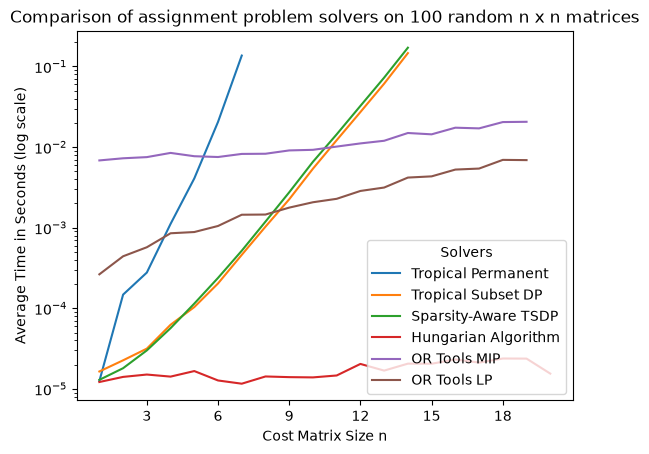

In [48]:
xvals = [i+1 for i in range(len(averagetimelist))]
yvalstrop = [averagetimelist[i][0] for i in range(len(averagetimelist))]
yvalstropsubsetDP = [averagetimelist[i][1] for i in range(len(averagetimelist))]
yvalsftropsubsetDP = [averagetimelist[i][2] for i in range(len(averagetimelist))]
yvalslinearsum = [averagetimelist[i][3] for i in range(len(averagetimelist))]
yvalsMIP = [averagetimelist[i][4] for i in range(len(averagetimelist))]
yvalsLP = [averagetimelist[i][5] for i in range(len(averagetimelist))]
ax=sns.lineplot(x=xvals,y=yvalstrop, label = "Tropical Permanent")
ax=sns.lineplot(x=xvals,y=yvalstropsubsetDP, label = "Tropical Subset DP")
ax=sns.lineplot(x=xvals,y=yvalsftropsubsetDP, label = "Sparsity-Aware TSDP")
ax=sns.lineplot(x=xvals,y=yvalslinearsum, label = "Hungarian Algorithm")
ax=sns.lineplot(x=xvals,y=yvalsMIP, label = "OR Tools MIP")
ax=sns.lineplot(x=xvals,y=yvalsLP, label = "OR Tools LP")
ax.set_title("Comparison of assignment problem solvers on 100 random n x n matrices")
ax.set(xlabel="Cost Matrix Size n", ylabel="Average Time in Seconds (log scale)")
ax.set(yscale="log")
# Force x-axis to show only integer values
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(
    title="Solvers",          
    loc="lower right",               
    fontsize=10                      
)

For very small instances, fixed solver overhead can dominate runtime, allowing the lightweight naive tropical recursion to outperform the general-purpose MIP solver. This advantage is short-lived: as $n$ increases, the factorial growth of the recursive method quickly overwhelms its low overhead, while the subset DP scales substantially better.

More broadly, the results show that solver choice matters at least as much as mathematical formulation. A general-purpose MIP formulation solves the same optimization problem, but an assignment-specific solver is dramatically faster because it exploits the problem's combinatorial structure directly. Comparing the tropical methods only against MIP would therefore substantially understate the performance achievable with specialized algorithms.

## Exploiting Sparsity

The previous experiments show that computational performance improves as the algorithms exploit more of the assignment problem's structure. This raises a related question: **can additional structure in the cost matrix itself also improve performance?**

To investigate this, I consider sparse assignment problems in which only a fraction of worker-job pairs are feasible. The ordinary tropical subset DP still considers every possible transition, even when many assignments are forbidden. I therefore modify the algorithm so that it checks feasibility before making a recursive call and immediately skips forbidden assignments.

The worst-case complexity remains $O(n2^n)$, since a dense instance may still require exploring every transition. On sparse instances, however, the feasibility-aware algorithm can avoid substantial computation by pruning branches that cannot contribute to a feasible assignment.

The following experiment compares the ordinary and sparsity-aware tropical subset DP as the density of feasible assignments varies.

### Generating Sparse Assignment Problems

To study the effect of sparsity systematically, I generate cost matrices with a prescribed density $d$, where $d$ is the fraction of the $n^2$ possible assignments that are feasible.

Simply selecting feasible entries at random can produce a matrix with no perfect matching, particularly at low densities. In that case, differences in solver behavior could reflect infeasibility rather than the effect of sparsity itself. To avoid this, each generated matrix is guaranteed to contain at least one feasible assignment.

The construction proceeds as follows:

1. Start with an $n \times n$ matrix in which every assignment is forbidden, represented by a cost of $1000$.
2. Choose a random permutation $\sigma$ and make the $n$ entries $(i,\sigma(i))$ feasible. These entries form a perfect matching, guaranteeing that the assignment problem has a solution.
3. Randomly select additional entries until approximately $d n^2$ entries are feasible in total.
4. Assign each feasible entry an independent random cost between 0 and 1.

This construction lets us vary assignment density while keeping the matrix size fixed and guaranteeing feasibility. At low density, most potential assignments are forbidden; as $d$ approaches 1, the matrices approach fully dense random assignment problems.

In [13]:
# make matrices with a guaranteed solution and specified density 

def sparse_assignment_matrix(n, d):
    # Number of allowed (non-forbidden) entries
    k = round(d * n * n)

    # A feasible assignment requires at least n allowed entries
    if k < n:
        raise ValueError(
            f"Density {d} is too low for n={n}: "
            f"need at least {n} allowed entries."
        )

    # Start with everything forbidden
    X = np.full((n, n), 1000.0)

    # Choose a random permutation to guarantee a feasible assignment
    p = np.random.permutation(n)

    # These n entries must be allowed
    guaranteed = {i * n + p[i] for i in range(n)}

    # Choose the remaining allowed entries
    all_entries = set(range(n * n))
    remaining = list(all_entries - guaranteed)

    extra = np.random.choice(
        remaining,
        size=k - n,
        replace=False
    )

    allowed = list(guaranteed) + list(extra)

    # Give every allowed entry a random cost
    for idx in allowed:
        i = idx // n
        j = idx % n
        X[i, j] = np.random.rand()

    return X

The function below runs the comparison between the two tropical solvers on sparse matrices.

In [14]:
def sparsecomparison(n, d): #for a random nxn and density d, return the time for tropical subset dp and forbidden tropical subset dp

    X = sparse_assignment_matrix(n, d) # make a random sparse matrix

    tropsubsetDPtime = timeit.timeit(lambda: tropsubsetDPassignment(X), number=1)

    ftropsubsetDPtime = timeit.timeit(lambda: forbiddentropsubsetDPassignment(X), number=1)
    
    return [tropsubsetDPtime,ftropsubsetDPtime,d]

In [15]:
def sparsedata(n,k): #run k tests on nxn matrices, return  average times
    densitylist = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
    data = []
    for d in densitylist:
        newdata = [sparsecomparison(n,d) for i in range(k)]
        data.extend(newdata)
    return data

### Sparsity Experiment

To isolate the effect of sparsity, I fix the matrix size at $n=10$ and vary the density of feasible assignments. For each density, I generate repeated random instances using the procedure above and measure the runtime of both the ordinary tropical subset DP and the sparsity-aware version.

The ordinary subset DP does not use feasibility information to reduce its search, so its runtime should be relatively insensitive to density. In contrast, the sparsity-aware algorithm can skip forbidden transitions, so we expect its computational advantage to be largest at low densities and to diminish as the matrix becomes dense.

The figure below shows the average runtime at each density, with error bars indicating the variability across repeated trials.

In [16]:
n = 10 # choose matrix size -- note above in density list, the lowest value needs to be larger than 1/n or you get error
k = 200 # choose number of tests per density
sparsedatalist = sparsedata(n,k)

df = pd.DataFrame(
    sparsedatalist,
    columns=["ordinary_time", "forbidden_time", "density"]
)

summary = df.groupby("density").agg(
    ordinary_median=("ordinary_time", "median"),
    ordinary_q25=("ordinary_time", lambda x: x.quantile(0.25)),
    ordinary_q75=("ordinary_time", lambda x: x.quantile(0.75)),
    forbidden_median=("forbidden_time", "median"),
    forbidden_q25=("forbidden_time", lambda x: x.quantile(0.25)),
    forbidden_q75=("forbidden_time", lambda x: x.quantile(0.75))
).reset_index()

summary.head()


,density,ordinary_median,ordinary_q25,ordinary_q75,forbidden_median,forbidden_q25,forbidden_q75
0,0.1,0.005763,0.005256,0.006411,0.000040,0.000036,0.000048
1,0.2,0.005338,0.004859,0.006230,0.000144,0.000103,0.000219
2,0.3,0.006339,0.005296,0.007982,0.000628,0.000390,0.000928
3,0.4,0.005611,0.005127,0.006155,0.001512,0.001118,0.001946
4,0.5,0.005426,0.005098,0.005941,0.002832,0.002346,0.003302


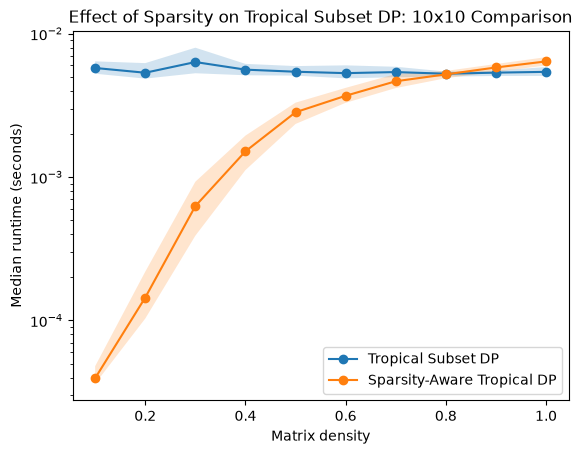

In [17]:
plt.plot(
    summary["density"],
    summary["ordinary_median"],
    marker="o",
    label="Tropical Subset DP"
)

plt.fill_between(
    summary["density"],
    summary["ordinary_q25"],
    summary["ordinary_q75"],
    alpha=0.2
)

plt.plot(
    summary["density"],
    summary["forbidden_median"],
    marker="o",
    label="Sparsity-Aware Tropical DP"
)

plt.fill_between(
    summary["density"],
    summary["forbidden_q25"],
    summary["forbidden_q75"],
    alpha=0.2
)

plt.xlabel("Matrix density")
plt.ylabel("Median runtime (seconds)")
plt.title("Effect of Sparsity on Tropical Subset DP: 10x10 Comparison")
plt.yscale("log")
plt.legend()
plt.show()

### Results

The ordinary tropical subset DP is almost completely insensitive to assignment density: its runtime remains essentially flat across the experiment. This is expected because the algorithm considers the same set of possible transitions regardless of whether an assignment is feasible.

The sparsity-aware DP behaves very differently. At density $d=0.1$, pruning forbidden assignments reduces runtime by roughly **two orders of magnitude**. As density increases, fewer transitions can be pruned and this advantage steadily decreases. By approximately $d=0.8$, the two algorithms have similar runtimes.

At very high densities, the sparsity-aware method becomes slightly slower than the ordinary subset DP. In this regime, nearly every transition is feasible, so the additional feasibility check introduces overhead without providing enough pruning to compensate.

**The key result is that structure in the data does not improve computational performance unless the algorithm is designed to exploit it.** The ordinary subset DP receives no practical benefit from sparsity, while a simple feasibility-aware modification produces substantial speedups on sparse instances. As the matrix becomes dense and that exploitable structure disappears, so does the computational advantage.

## Case Study: Chicago Taxi Assignment

The experiments above study the assignment problem from an algorithmic perspective: given a cost matrix, how efficiently can we find an optimal assignment? In a real-world optimization problem, however, the cost matrix is not given. It must first be constructed from data and a set of modeling assumptions.

To explore this modeling side of operations research, I use data from the **Chicago Taxi Rides dataset (January 2016)** to formulate a simplified taxi dispatch problem. At a given point in time, suppose we have a set of available taxis and a set of pickup requests. The goal is to assign taxis to requests so as to minimize the total distance taxis must travel before reaching their passengers.

The case study follows the pipeline

$$
\text{raw trip data}
\longrightarrow
\text{available taxis and pickup requests}
\longrightarrow
\text{cost matrix}
\longrightarrow
\text{optimal assignment}
\longrightarrow
\text{interpretation}.
$$

Because the public dataset does not contain all of the information required to reconstruct actual dispatch decisions, this should be viewed as a **retrospective optimization model rather than a reconstruction of Chicago's historical taxi dispatch system**. The analysis therefore requires explicit choices about how taxi availability, pickup requests, and repositioning costs are represented.

The following sections construct these pieces from the trip data and then solve the resulting assignment problem.

In [18]:
taxi_file = PROJECT_ROOT / "data" / "chicago_taxi_trips_2016_01.csv"

rawdf = pd.read_csv(taxi_file)
rawdf.head()

,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,85.0,2016-1-13 06:15:00,2016-1-13 06:15:00,180.0,0.40,NaN,NaN,24.0,24.0,4.50,0.00,0.0,0.0,4.50,Cash,107.0,199.0,510.0,199.0,510.0
1,2776.0,2016-1-22 09:30:00,2016-1-22 09:45:00,240.0,0.70,NaN,NaN,NaN,NaN,4.45,4.45,0.0,0.0,8.90,Credit Card,NaN,NaN,NaN,NaN,NaN
2,3168.0,2016-1-31 21:30:00,2016-1-31 21:30:00,0.0,0.00,NaN,NaN,NaN,NaN,42.75,5.00,0.0,0.0,47.75,Credit Card,119.0,NaN,NaN,NaN,NaN
3,4237.0,2016-1-23 17:30:00,2016-1-23 17:30:00,480.0,1.10,NaN,NaN,6.0,6.0,7.00,0.00,0.0,0.0,7.00,Cash,NaN,686.0,500.0,686.0,500.0
4,5710.0,2016-1-14 05:45:00,2016-1-14 06:00:00,480.0,2.71,NaN,NaN,32.0,NaN,10.25,0.00,0.0,0.0,10.25,Cash,NaN,385.0,478.0,NaN,NaN


### Data Preparation

Before constructing the assignment problem, the raw taxi data require several preprocessing steps.

One important complication is that the public dataset does not store the original latitude and longitude values directly. To reduce the size of high-cardinality columns, geographic coordinates were replaced by integer codes. I use the accompanying `column_remapping.json` file to map these codes back to their corresponding latitude and longitude values.

After restoring the geographic coordinates, I clean and filter the trip records to retain the information needed for the assignment model. In particular, the analysis requires:

- a taxi identifier, so that trips belonging to the same taxi can be related;
- trip start and end times, used to construct the retrospective snapshot;
- pickup coordinates, representing passenger requests; and
- dropoff coordinates, representing locations where taxis become available.

Rows without the geographic or temporal information required for the analysis are removed. The resulting DataFrame provides the cleaned trip records from which available taxis and pickup requests will be constructed.

This preprocessing step is essential: the optimization model operates on a cost matrix, but constructing a meaningful cost matrix first requires translating the raw trip records into usable geographic and temporal information.

In [19]:
remapping_file = PROJECT_ROOT / "data" / "column_remapping.json"

with open(remapping_file, "r") as f:
    remapping = json.load(f)

print(remapping.keys())

dict_keys(['taxi_id', 'company', 'pickup_census_tract', 'dropoff_census_tract', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])


In [20]:
# clean data
df = rawdf
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp']) ## make everything datetime
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp']) ## make everything datetime
# remove irrelevant columns
df = df[['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude']]
# remove rows with NAN
df = df.dropna(subset=['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude'])
# remapping to get lat / long correct
df["pickup_latitude"] = (
    df["pickup_latitude"]
    .astype(int)
    .astype(str)
    .map(remapping["pickup_latitude"])
)
# remapping to get lat / long correct
df["pickup_longitude"] = (
    df["pickup_longitude"]
    .astype(int)
    .astype(str)
    .map(remapping["pickup_longitude"])
)
# remapping to get lat / long correct
df["dropoff_latitude"] = (
    df["dropoff_latitude"]
    .astype(int)
    .astype(str)
    .map(remapping["dropoff_latitude"])
)
# remapping to get lat / long correct
df["dropoff_longitude"] = (
    df["dropoff_longitude"]
    .astype(int)
    .astype(str)
    .map(remapping["pickup_longitude"])
)
# remove rows with NAN
df = df.dropna(subset=['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude'])

# fix types
columns = [
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude"
]

for col in columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df.head()

,taxi_id,trip_start_timestamp,trip_end_timestamp,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,85.0,2016-01-13 06:15:00,2016-01-13 06:15:00,41.901207,-87.676356,41.901207,-87.676356
3,4237.0,2016-01-23 17:30:00,2016-01-23 17:30:00,41.944227,-87.655998,41.944227,-87.655998
5,1987.0,2016-01-08 18:15:00,2016-01-08 18:45:00,41.899602,-87.633308,41.965812,-87.655879
7,6400.0,2016-01-26 04:15:00,2016-01-26 04:15:00,41.953582,-87.723452,41.953582,-87.723452
8,7418.0,2016-01-22 11:30:00,2016-01-22 11:45:00,41.892508,-87.626215,41.884987,-87.620993


### Constructing Available Taxis and Pickup Requests

To construct a retrospective dispatch snapshot, I first identify **available taxis** as taxis that completed a trip at the selected timestamp. The dropoff location of each completed trip is treated as the location from which that taxi becomes available for a new assignment.

I then use subsequent trip starts as proxies for **pickup requests**. I consider trips beginning within the following 2 hours and retain requests associated with taxis in the available-taxi set (the choice 2 hours was made because this is how long it takes to get from downtown to O'Hare in traffic, which is a common trip). The pickup location of each of these trips represents a candidate request to which an available taxi could have been assigned.

Because trip timestamps are rounded to 15-minute intervals, this procedure does not reconstruct the exact chronological sequence of taxi availability and dispatch. Instead, it creates a plausible retrospective snapshot from which to formulate and analyze an assignment problem.

In [21]:
# first, make a function that retrieves taxis whose trips ended at a given time stamp
# feed in a string "%Y-%m-%d %H:%M:%S"
def availabletaxis(time):
   window_start_time = datetime.strptime(time, "%Y-%m-%d %H:%M:%S")
   filtered_df = df[(df['trip_end_timestamp'] == window_start_time)]
   filtered_df = filtered_df[['taxi_id','dropoff_latitude','dropoff_longitude']]
   filtered_df = filtered_df.rename(columns={'dropoff_latitude':'available_latitude', 'dropoff_longitude':'available_longitude'})
   return filtered_df

We set the example time used for the computations below. This is January 13, 2016 at 8:15 am. This time was selected because there were a reasonably large number of taxis available (518).

In [22]:
exampletime= '2016-01-13 08:15:00'
taxis = availabletaxis(exampletime)
taxis


,taxi_id,available_latitude,available_longitude
1609,485.0,41.880994,-87.632746
3347,6978.0,41.899156,-87.626211
3885,6581.0,41.965812,-87.655879
4089,698.0,41.922686,-87.649489
5078,2235.0,41.880994,-87.632746
...,...,...,...
1698887,4999.0,41.867902,-87.642959
1700535,3595.0,41.892508,-87.626215
1700716,2122.0,41.892508,-87.626215
1702827,4908.0,41.880994,-87.632746


In [23]:
# trip requests -- we will use 'trip start timestamp' as a proxy for request time. we will use trips that start within the next 2 hours (reasoning: it can take 2 hours to get from downtown to airport in traffic)
# feed in a string "%Y-%m-%d %H:%M:%S"
def triprequests(time):
   window_start_time = datetime.strptime(time, "%Y-%m-%d %H:%M:%S")
   window_end_time = window_start_time + timedelta(minutes=120)
   filtered_df = df[(df['trip_start_timestamp'] >= window_start_time) & (df['trip_start_timestamp'] <= window_end_time)]
   filtered_df = filtered_df[['taxi_id','trip_start_timestamp', 'pickup_latitude', 'pickup_longitude']]
   filtered_df = filtered_df.rename(columns={'trip_start_timestamp': 'request_timestamp', 'pickup_latitude':'request_latitude', 'pickup_longitude':'request_longitude'})
   merged_df = pd.merge(availabletaxis(time),filtered_df, on='taxi_id')
   merged_df=merged_df.drop_duplicates(subset=['taxi_id'])
   return merged_df

In [24]:
requests = triprequests(exampletime)
print(len(requests))
requests.head()


518


,taxi_id,available_latitude,available_longitude,request_timestamp,request_latitude,request_longitude
0,485.0,41.880994,-87.632746,2016-01-13 09:00:00,41.900221,-87.629105
7,6978.0,41.899156,-87.626211,2016-01-13 08:15:00,41.899156,-87.626211
10,6581.0,41.965812,-87.655879,2016-01-13 08:30:00,41.965812,-87.655879
11,698.0,41.922686,-87.649489,2016-01-13 08:15:00,41.944227,-87.655998
16,2235.0,41.880994,-87.632746,2016-01-13 08:30:00,41.885300,-87.642808


### Constructing the Cost Matrix

To formulate the taxi dispatch problem as an assignment problem, we need a cost for assigning each available taxi $i$ to each pickup request $j$. I use the geographic distance between the taxi's available location and the request's pickup location as this cost:

$$
c_{ij}
=
\text{distance from available taxi } i
\text{ to pickup request } j.
$$

Because the data provide latitude and longitude rather than road-network travel times, I approximate repositioning distance using the **Haversine distance**, which computes the great-circle distance between two points on the Earth's surface.

This is a simplification: straight-line geographic distance does not account for the street network, traffic, or actual driving routes. A production dispatch model would ideally use estimated travel time or road distance. Here, Haversine distance provides a simple and interpretable proxy that allows the geographic data to be translated into an assignment cost matrix.

The function below computes Haversine distance in miles between two latitude-longitude pairs.

In [25]:
# Straight-line geographic distance is used as a proxy for repositioning cost.
# A production dispatch system would preferably use estimated road-network travel time, incorporating street topology and current traffic conditions.
# distance function for lat and lon
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1, lon1, lat2, lon2 = np.radians(
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [26]:
def costmatrix(time): # make a cost matrix with rows = taxis, columns = requests, and cost is distance 
    requestsdf = triprequests(time)
    distances = [[haversine(requestsdf['available_latitude'].iloc[i], requestsdf['available_longitude'].iloc[i],
                            requestsdf['request_latitude'].iloc[j], requestsdf['request_longitude'].iloc[j])
         for j in range(len(requestsdf))] for i in range(len(requestsdf))]
    return np.array(distances)

In [27]:
C = costmatrix(exampletime) # this takes several seconds to run. 

# Display a small sample of the cost matrix
cost_sample = pd.DataFrame(
    C[:8, :8],
    index=[f"Taxi {i}" for i in range(8)],
    columns=[f"Request {j}" for j in range(8)]
)

cost_sample.round(2)

,Request 0,Request 1,Request 2,Request 3,Request 4,Request 5,Request 6,Request 7
Taxi 0,1.34,1.30,5.98,4.53,0.60,0.60,15.46,7.11
Taxi 1,0.17,0.00,4.85,3.47,1.28,1.28,15.26,6.04
Taxi 2,4.74,4.85,0.00,1.49,5.60,5.60,12.73,1.25
Taxi 3,1.87,2.02,3.00,1.53,2.61,2.61,13.60,4.10
Taxi 4,1.34,1.30,5.98,4.53,0.60,0.60,15.46,7.11
Taxi 5,0.60,0.44,5.23,3.88,1.37,1.37,15.68,6.43
Taxi 6,15.10,15.26,12.73,12.92,14.86,14.86,0.00,11.90
Taxi 7,1.34,1.30,5.98,4.53,0.60,0.60,15.46,7.11


### Optimizing Taxi Assignments

With the cost matrix constructed, the taxi dispatch problem is now a standard linear assignment problem. I solve it using SciPy's `linear_sum_assignment`, which finds the one-to-one matching between available taxis and pickup requests that minimizes total estimated repositioning distance.

If $\sigma$ denotes the resulting optimal assignment, the average repositioning distance is

$$
\frac{1}{n}\sum_{i=1}^n c_{i,\sigma(i)}.
$$

This gives the average Haversine distance an available taxi would need to travel to reach its assigned pickup request under the optimized matching.

The function below constructs the cost matrix for a specified snapshot, solves the assignment problem, and returns this average optimized repositioning distance.

In [28]:
## solve the assignment problem, and then give mean displacement
## The optimal assignment has total estimated repositioning distance of X miles, averaging Y miles per taxi.

def best_mean_distance(time):
    C = costmatrix(time)
    row_ind, col_ind = linear_sum_assignment(C)

    assigned_distances = C[row_ind, col_ind]

    mean_distance = assigned_distances.mean()
    return(mean_distance)

best_mean_distance(exampletime)

np.float64(0.6468372801326099)

### Observed-Trip Proxy

The optimized assignment above answers a hypothetical question: given the available taxis and candidate pickup requests in a snapshot, what matching would minimize total repositioning distance?

We can also construct a comparison based on the trips that actually appear in the dataset. For each taxi in the available-taxi set, I identify a subsequent trip by that same taxi and measure the Haversine distance from its inferred available location to that trip's pickup location. This gives a reference point for the distances associated with the taxi movements represented in the data.

This quantity should **not** be interpreted as the actual dispatch distance or as a reconstruction of the decisions made by taxi operators. Several limitations prevent that interpretation:

- **Timestamps are rounded to 15-minute intervals.** We cannot determine the exact sequence of events within a timestamp bin, so we cannot know precisely when a taxi became available or when it was dispatched.
- **The subsequent trip is only a proxy for the next assignment.** The selected trip was completed by the same taxi within the following two hours, but it cannot necessarily be identified as the immediate next trip after the taxi became available.
- **The data do not record the dispatch decision itself.** We observe completed trips, not the matching process that produced them.
- **Haversine distance is only a proxy for repositioning distance.** It measures straight-line geographic distance rather than the actual route driven.
- **Geographic locations are aggregated.** Some trips share identical reported coordinates, so a zero Haversine distance means that the taxi and request have the same reported location, not necessarily the same physical point.

For these reasons, I refer to this quantity as the **observed-trip proxy** rather than an actual dispatch distance. Its purpose is to provide a real-data reference against which the optimized and random assignments can be compared.

In [29]:

def observed_proxy_mean_distance(time):
    df = triprequests(time)
    displacement_distances = np.array([haversine(df['available_latitude'].iloc[i], df['available_longitude'].iloc[i],
                            df['request_latitude'].iloc[i], df['request_longitude'].iloc[i]) for i in range(len(df))])
    return displacement_distances.mean()

observed_proxy_mean_distance(exampletime)

np.float64(1.5648693053796443)

### Random Assignment Baseline

As a simple baseline, I also compare the optimized assignment with a **random one-to-one matching** between the available taxis and pickup requests. A random permutation of the requests is generated so that every taxi is assigned to exactly one request and every request to exactly one taxi, but geographic distance plays no role in determining the matching.

This provides a useful reference for evaluating the value of optimization. The optimized and random assignments satisfy the same one-to-one assignment constraints; the difference is that the optimized solution explicitly minimizes repositioning distance, while the random assignment ignores the cost matrix.

Because the result of a single random matching can vary substantially, I generate repeated random assignments and compare the optimized solution with the average repositioning distance across these trials.

In [30]:
## compare this against random assignments
def random_mean_distance(C):
    m, n = C.shape

    if m <= n:
        row_ind = np.arange(m)
        col_ind = np.random.choice(n, size=m, replace=False)
    else:
        row_ind = np.random.choice(m, size=n, replace=False)
        col_ind = np.arange(n)

    random_assigned_distances = C[row_ind, col_ind]
    mean_distance = random_assigned_distances.mean()
    return(mean_distance)

In [31]:
# compare the optimized assignment assignment against 100 randoms
def compare_mean_distance(time):
    C = costmatrix(time)
    times = np.array([random_mean_distance(C) for i in range (100)])
    return(times.mean())

compare_mean_distance(exampletime)

np.float64(3.2024649477349123)

Finally, the following cell produces a summary statement comparing the three assignments.

In [32]:
def summary_statement(time):
    C = costmatrix(time)
    rand = compare_mean_distance(time)
    actual = observed_proxy_mean_distance(time)
    good = best_mean_distance(time)
    return f"The optimal assignment average estimated repositioning distance of {good} miles per taxi, the observed proxy repositioning distance was {actual}, where a random assignment gives {rand} average estimated miles of repositioning."

summary_statement(exampletime)

'The optimal assignment average estimated repositioning distance of 0.6468372801326099 miles per taxi, the observed proxy repositioning distance was 1.5648693053796443, where a random assignment gives 3.215791674851794 average estimated miles of repositioning.'

### Visualizing the Assignment

To make the optimization result more concrete, the figure below visualizes the assignments for the snapshot at **January 13, 2016 at 8:15 AM**.

Blue points represent the inferred locations of available taxis, while orange markers represent pickup requests. Each gray line connects a taxi to the request assigned to it by the distance-minimizing solution.

The map provides a geographic view of the optimization problem: rather than assigning taxis independently, the assignment algorithm considers all taxi-request pairs simultaneously and finds the one-to-one matching that minimizes the total estimated repositioning distance.

The underlying locations are based on the spatially aggregated coordinates provided in the public dataset, so the map should be interpreted as a visualization of the modeled assignment rather than a reconstruction of the precise physical positions of taxis and passengers.

In [33]:
## Visualize the assignment
time = '2016-01-13 08:15:00'
requests = triprequests(time)
C = costmatrix(time)
row_ind, col_ind = linear_sum_assignment(C)
summary_statement(time)

'The optimal assignment average estimated repositioning distance of 0.6468372801326099 miles per taxi, the observed proxy repositioning distance was 1.5648693053796443, where a random assignment gives 3.204546715971335 average estimated miles of repositioning.'

In [34]:
# more info about the figure
assigned_distances = C[row_ind, col_ind]

print("Number of available taxis:", C.shape[0])
print("Number of requests:", C.shape[1])
print("Total repositioning distance:", assigned_distances.sum())
print("Mean repositioning distance:", assigned_distances.mean())
print("Median repositioning distance:", np.median(assigned_distances))

Number of available taxis: 518
Number of requests: 518
Total repositioning distance: 335.0617111086919
Mean repositioning distance: 0.6468372801326099
Median repositioning distance: 0.0


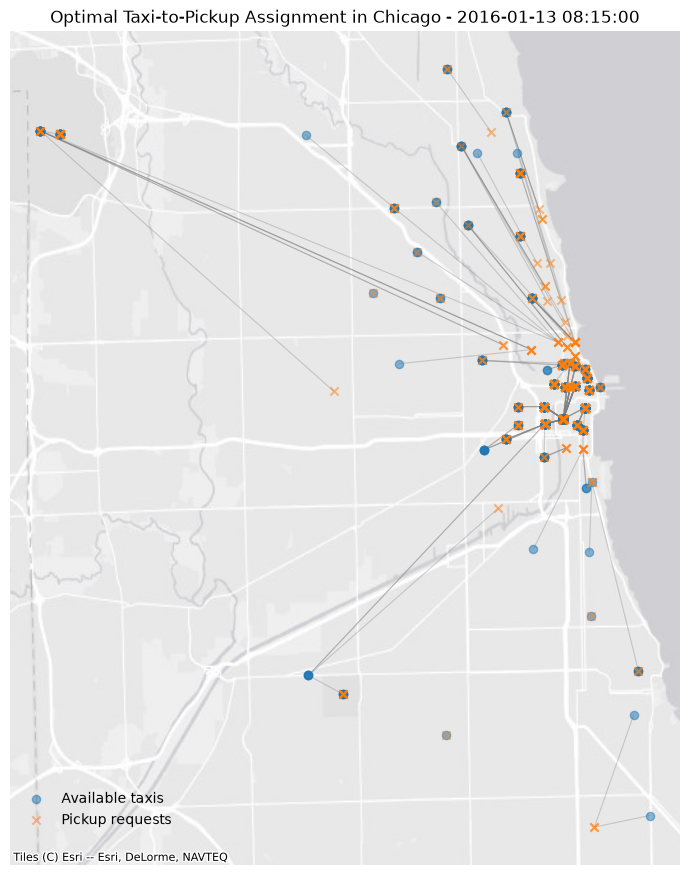

In [52]:
# now make the plot

fig, ax = plt.subplots(figsize=(7, 9))


## Turn taxi data in to geo data

taxis_geo = gpd.GeoDataFrame(
    requests.copy(),
    geometry=gpd.points_from_xy(
        requests["available_longitude"],
        requests["available_latitude"]
    ),
    crs="EPSG:4326"
)

requests_geo = gpd.GeoDataFrame(
    requests.copy(),
    geometry=gpd.points_from_xy(
        requests["request_longitude"],
        requests["request_latitude"]
    ),
    crs="EPSG:4326"
)


## change to base map coords
taxis_geo = taxis_geo.to_crs(epsg=3857)
requests_geo = requests_geo.to_crs(epsg=3857)


# Assignment lines FIRST so they appear behind points
for taxi_i, request_j in zip(row_ind, col_ind):

    taxi = taxis_geo.iloc[taxi_i].geometry
    request = requests_geo.iloc[request_j].geometry

    ax.plot(
        [taxi.x, request.x],
        [taxi.y, request.y],
        color="gray",
        linewidth=0.8,
        alpha=0.35,
        zorder=1
    )


# Available taxis
ax.scatter(
    taxis_geo.geometry.x,
    taxis_geo.geometry.y,
    s=35,
    marker="o",
    label="Available taxis",
    alpha=0.5,
    zorder=2
)

# Pickup requests
ax.scatter(
    requests_geo.geometry.x,
    requests_geo.geometry.y,
    s=35,
    marker="x",
    label="Pickup requests",
    alpha=0.5,
    zorder=3
)

ctx.add_basemap(
     ax,
     source=ctx.providers.Esri.WorldGrayCanvas
 )



#ax.set_xlabel("Longitude")
#ax.set_ylabel("Latitude")
ax.set_axis_off()
ax.set_title(f"Optimal Taxi-to-Pickup Assignment in Chicago - {time}")



# Cleaner frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower left",
    bbox_to_anchor=(0, 0.03),
    frameon=False
)


plt.tight_layout()
plt.show()



### Interpretation

Because pickup and dropoff locations in the public dataset are spatially aggregated, multiple trips may share identical reported coordinates. Consequently, some optimized repositioning distances are zero. These should be interpreted as a taxi and pickup request occurring at the same reported geographic location, rather than necessarily at exactly the same physical point.

The figure also illustrates an important feature of the assignment problem: the optimal solution is **global rather than greedy**. Assigning each taxi independently to its nearest request would not guarantee a feasible one-to-one matching, since multiple taxis may prefer the same request. Instead, the assignment algorithm considers all taxi-request pairings simultaneously and chooses the combination that minimizes total repositioning distance.

For this snapshot, the optimized assignment produces an average estimated repositioning distance of **0.65 miles per taxi**, compared with **3.21 miles under random one-to-one assignment**. This corresponds to an approximately **80% reduction in estimated repositioning distance** relative to the random baseline.

## Conclusions

This project began with a natural question arising from the tropical formulation of the assignment problem: **does viewing the assignment problem as a tropical permanent provide computational value?**

For the problems studied here, the answer is largely no. Direct recursive evaluation of the tropical permanent provides a conceptually natural algorithm, but its factorial complexity makes it impractical beyond very small instances. Recognizing and memoizing repeated subproblems leads to a substantial improvement through subset dynamic programming, reducing the complexity to $O(n2^n)$. Nevertheless, the specialized assignment solver remains dramatically faster, demonstrating the advantage of algorithms designed specifically for the combinatorial structure of the problem.

The sparsity experiments provide a second lesson about algorithm design. Sparse structure alone does not improve the ordinary subset DP, because the algorithm does not use feasibility information when exploring transitions. Once the algorithm is modified to explicitly prune forbidden assignments, however, sparse instances become substantially cheaper to solve. At low densities this produces improvements of roughly two orders of magnitude, while the advantage disappears as the matrices become dense. Structure is computationally useful only when the algorithm is designed to exploit it.

The LP and MIP formulations provide another perspective on the same problem. The assignment problem can be expressed naturally as a binary optimization model, but its special polyhedral structure makes the integrality constraints unnecessary: the LP relaxation has an integral optimal solution. At the same time, the computational experiments show that a mathematically valid general-purpose formulation is not necessarily the most computationally efficient way to solve a structured problem.

Finally, the Chicago taxi case study shifts the focus from solving a given cost matrix to constructing one from real data. Raw trip records must first be translated into inferred taxi availability, candidate pickup requests, and a meaningful cost function. Under the simplified retrospective model used here, the optimized assignment achieves an average estimated repositioning distance of **0.65 miles per taxi**, compared with **3.21 miles for random one-to-one matching**, a reduction of approximately **80%**. The observed-trip proxy provides an additional reference point of **1.56 miles per taxi**, although the temporal and geographic limitations of the dataset prevent interpreting this quantity as a reconstruction of actual historical dispatch decisions.

Taken together, these experiments trace the assignment problem from mathematical formulation through algorithm design, computational benchmarking, and real-world modeling. The tropical perspective does not outperform specialized classical assignment methods, but it provides a useful route into a broader optimization lesson: effective computation depends on identifying structure, designing algorithms that exploit it, and making modeling assumptions that connect mathematical optimization to the data available in practice.